In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import LocalOutlierFactor
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from enum import Enum
import os
from sklearn.ensemble import GradientBoostingClassifier
import time
import torch
from typing import List, Dict, Any

/home/grinenko/anaconda3/envs/anna/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/home/grinenko/anaconda3/envs/anna/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from temain import TemainProcess
import importlib
import v2_utils
import generators
import autoencoders
importlib.reload(v2_utils)
# importlib.reload(generators)
# importlib.reload(autoencoders)
from v2_utils import CSVDataLoader, ExperimentRunner, plot_with_anomalies, AdvancedDetectionEvaluator, BaseAnomalyDetector, ExperimentRunner
from autoencoders import RecurrentAutoencoder
from generators import ParallelDataGenerator, SingleProcessGenerator, N_DV

In [3]:


def run_experiments_by_anomaly(
        anomaly_numbers: List[int],
        data_dir_template: str = "./gen_data/gen_data_{}",
        model_params_list=None,
        file_fraction=0.01,
        anomaly_ratio=0.11,
        max_samples=None,
        result_title="",
        results_path="./results/my",
        window=30,
    ):
    normal_dir = data_dir_template.format(0)
    all_best_models = []
    all_best_per_detector = []
    
    for i in anomaly_numbers:
        print(f"\n{'='*50}")
        print(f"Запуск экспериментов для аномалии {i}")
        print(f"{'='*50}")
        start_time = time.time()
        
        data_dir = data_dir_template.format(i)
        autoencoder = RecurrentAutoencoder(
                    input_dim=53,
                    window_size=30,
                    hidden_dim=64,
                    latent_dim=32,
                    num_layers=1
                )
        model_saved_path = f"./models/new_autoencoder_w15.pth"
        autoencoder.load_state_dict(torch.load(model_saved_path))
        autoencoder.eval()
        
        data_gen = CSVDataLoader(data_dir, 
                                 file_fraction=file_fraction,
                                 normal_dir=normal_dir, 
                                 max_samples=max_samples,
                                 anomaly_ratio=anomaly_ratio,
                                 shuffle=True,
                                 normalize=True)
        
        runner = ExperimentRunner(data_gen, evaluator=AdvancedDetectionEvaluator)
        
        runner.register_detector(
            'IsolationForest', 
            IsolationForest,
            {'random_state': 42, 'contamination': 0.1}
        )

        runner.register_detector(
            'LocalOutlierFactor', 
            LocalOutlierFactor,
            {'contamination': 0.1, "novelty": True}
        )

        runner.register_detector(
            'OneClassSVM', 
            OneClassSVM,
            {'kernel': 'linear', 'nu': 0.1} # {'kernel': 'rbf', 'gamma': 'auto', 'nu': 0.1}
        )
        # runner.register_detector(
        #     'GradientBoosting', 
        #     GradientBoostingClassifier,
        #     {'random_state': 42}
        # )
        
        results = runner.run_comprehensive_experiments(
            model_params_list=model_params_list,
            test_delays=None,
            autoencoder=autoencoder,
            window=window,
        )
        
        filename = f"{results_path}/experiments_results_{i}.csv"
        # results.to_csv(filename, index=False)
        # print(f"Результаты сохранены в {filename}")
        
        best_pr = runner.get_best_models('pr_auc', top_k=1)
        best_pr['anomaly_number'] = i
        best_pr['best_by_metric'] = 'pr_auc'
        all_best_models.append(best_pr)
        
        best_roc = runner.get_best_models('roc_auc', top_k=1)
        best_roc['anomaly_number'] = i
        best_roc['best_by_metric'] = 'roc_auc'
        all_best_models.append(best_roc)
        # f1 ?
        
        best_per_detector = runner.get_best_per_detector('pr_auc')
        if not best_per_detector.empty:
            best_per_detector['anomaly_number'] = i
            all_best_per_detector.append(best_per_detector)

        best_pr.iloc[0]["survival_km"].plot_survival_function()
        plt.title('Функции выживаемости времени обнаружения аномалий')
        plt.ylabel('Вероятность необнаружения аномалии')
        plt.xlabel('Время (шаги)')
        # plt.ylim(0, 1)
        plt.grid(True)
        plt.show()
        
        print(f"Аномалия {i}:")
        print(f"  - Лучший PR AUC: {best_pr['pr_auc'].iloc[0]:.4f} ({best_pr['detector'].iloc[0]})")
        print(f"  - Лучший ROC AUC: {best_roc['roc_auc'].iloc[0]:.4f} ({best_roc['detector'].iloc[0]})")
        # print(f"  - Лучший F1: {best_f1['f1_score'].iloc[0]:.4f} ({best_f1['detector'].iloc[0]})")
        cur = time.time()
        print(f"\n-------------------\nВремя выполнения: {cur - start_time:.4f} секунд\n")
    
    if all_best_models and all_best_per_detector:
        summary_df = pd.concat(all_best_models, ignore_index=True)
        numeric_cols = summary_df.select_dtypes(include=['number', 'bool', 'int64', 'float64']).columns
        summary_df = summary_df[numeric_cols]
        summary_filename = f"{results_path}/best_models_summary{'_' + result_title if result_title else ''}.csv"
        summary_df.to_csv(summary_filename, index=False)
        print(f"\nСводная таблица сохранена в {summary_filename}")
        
        per_detector_df = pd.concat(all_best_per_detector, ignore_index=True)
        pivot_df = per_detector_df.pivot_table(
            index='anomaly_number', 
            columns='detector', 
            values='pr_auc',
            aggfunc='first'
        )
        pivot_filename = f"{results_path}/pr_auc_pivot{'_' + result_title if result_title else ''}.csv"
        pivot_df.to_csv(pivot_filename)
        print(f"Сводная таблица PR AUC по детекторам сохранена в {pivot_filename}")
        return summary_df, pivot_df

    
    return None, None




Запуск экспериментов для аномалии 6
   Итого: X.shape=(66480, 15, 53), y.shape=(66480,)
   Доля аномалий: 0.0718
Применяем автоэнкодер к данным. Исходная форма: (66480, 15, 53)
После автоэнкодера: (66480, 32)
X_train.shape=(46536, 32), y_train.shape=(46536,), X_test.shape=(19944, 32), y_test.shape=(19944,), y_train.mean()=0.07183685748667698, y_test.mean()=0.07160048134777376


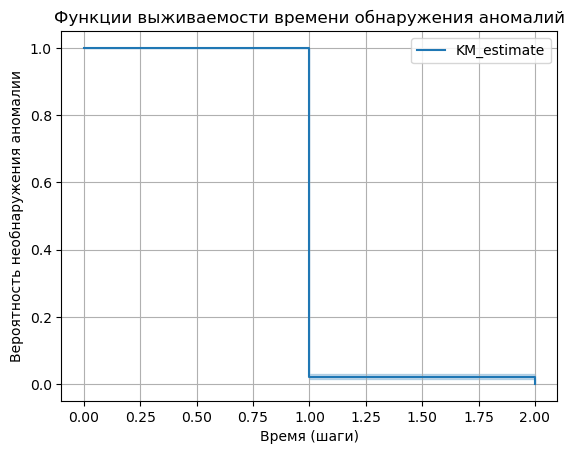

Аномалия 6:
  - Лучший PR AUC: 0.9936 (IsolationForest)
  - Лучший ROC AUC: 0.9978 (OneClassSVM)

-------------------
Время выполнения: 185.0576 секунд


Запуск экспериментов для аномалии 7
   Итого: X.shape=(66480, 15, 53), y.shape=(66480,)
   Доля аномалий: 0.0718
Применяем автоэнкодер к данным. Исходная форма: (66480, 15, 53)
После автоэнкодера: (66480, 32)
X_train.shape=(46536, 32), y_train.shape=(46536,), X_test.shape=(19944, 32), y_test.shape=(19944,), y_train.mean()=0.07183685748667698, y_test.mean()=0.07160048134777376


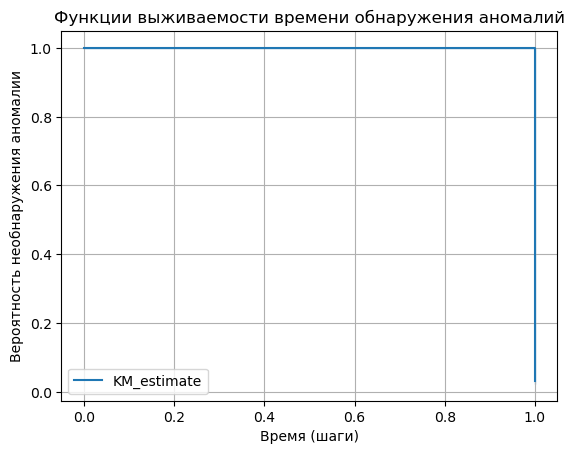

Аномалия 7:
  - Лучший PR AUC: 0.9941 (IsolationForest)
  - Лучший ROC AUC: 0.9982 (IsolationForest)

-------------------
Время выполнения: 178.4050 секунд


Запуск экспериментов для аномалии 8
   Итого: X.shape=(66480, 15, 53), y.shape=(66480,)
   Доля аномалий: 0.0718
Применяем автоэнкодер к данным. Исходная форма: (66480, 15, 53)
После автоэнкодера: (66480, 32)
X_train.shape=(46536, 32), y_train.shape=(46536,), X_test.shape=(19944, 32), y_test.shape=(19944,), y_train.mean()=0.07183685748667698, y_test.mean()=0.07160048134777376


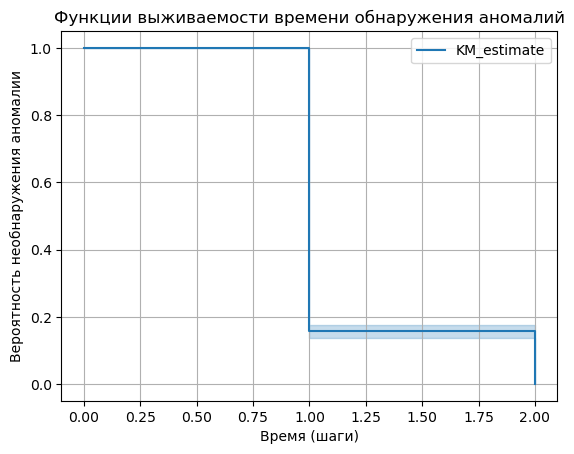

Аномалия 8:
  - Лучший PR AUC: 0.9291 (IsolationForest)
  - Лучший ROC AUC: 0.9625 (IsolationForest)

-------------------
Время выполнения: 175.9938 секунд


Сводная таблица сохранена в ./results/my/best_models_summary_unsupervised_with_autoencoder.csv
Сводная таблица PR AUC по детекторам сохранена в ./results/my/pr_auc_pivot_unsupervised_with_autoencoder.csv


In [4]:
model_params_list = {
    'IsolationForest': [
        # {'n_estimators': 200, 'contamination': 0.1, "random_state": 42},
        {'n_estimators': 100, 'max_samples': 'auto', 'contamination': 0.1, 'random_state': 42},
        {'n_estimators': 200, 'max_samples': 0.8, 'contamination': 0.05, 'random_state': 42},
        # {'n_estimators': 50, 'max_samples': 1.0, 'contamination': 0.15, 'random_state': 42},
        # {'n_estimators': 100, 'max_samples': 0.5, 'contamination': 'auto', 'random_state': 42}
    ],
    'LocalOutlierFactor': [
        # {'n_neighbors': 50, 'contamination': 0.1, 'novelty': True},
        {'n_neighbors': 20, 'contamination': 0.1, 'novelty': True},
        {'n_neighbors': 10, 'contamination': 0.05, 'novelty': True},
        # {'n_neighbors': 50, 'contamination': 0.15, 'novelty': True},
        # {'n_neighbors': 20, 'contamination': 'auto', 'novelty': True}
    ],
    'OneClassSVM': [
        # {'kernel': 'rbf', 'nu': 0.1},
        # {'kernel': 'rbf', 'nu': 0.15},
        {'kernel': 'linear', 'nu': 0.15},
        {'kernel': 'linear', 'nu': 0.2},
        # {'kernel': 'poly', 'nu': 0.15},
    ],
    # 'GradientBoosting': [
    #     {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1, 'random_state': 42},
    #     {'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.05, 'random_state': 42},
    #     {'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.01, 'random_state': 42},
    # ]
}

# anomaly_numbers = list(range(1, 20))
anomaly_numbers = [6, 7, 8]

summary, summary_detectors = run_experiments_by_anomaly(anomaly_numbers,
                                     data_dir_template="./gen_data/gen_data_{}",
                                     model_params_list=model_params_list,
                                     max_samples=100000,
                                     file_fraction=0.02,
                                     anomaly_ratio=0.07,
                                     window=15,
                                     result_title="unsupervised_with_autoencoder"
                                     )

In [5]:
summary

,roc_auc,pr_auc,optimal_thr,detection_latency,survival_mttd,n_estimators,contamination,random_state,size,anomaly_ratio,n_neighbors,nu,anomaly_number
0,0.997026,0.993616,0.752054,0.001444,0.021231,100.0,0.10,42.0,66480,0.071766,NaN,NaN,6
1,0.997810,0.992212,0.651581,0.001461,0.032555,NaN,NaN,NaN,66480,0.071766,NaN,0.2,6
2,0.998237,0.994110,0.644966,0.000000,0.622788,100.0,0.10,42.0,66480,0.071766,NaN,NaN,7
3,0.998237,0.994110,0.644966,0.000000,0.622788,100.0,0.10,42.0,66480,0.071766,NaN,NaN,7
4,0.962521,0.929147,0.309831,0.003344,0.156405,200.0,0.05,42.0,66480,0.071766,NaN,NaN,8
5,0.962521,0.929147,0.309831,0.003344,0.156405,200.0,0.05,42.0,66480,0.071766,NaN,NaN,8


In [6]:
summary_detectors

detector,IsolationForest,LocalOutlierFactor,OneClassSVM
anomaly_number,,,
6,0.993616,0.092309,0.992212
7,0.994110,0.056998,0.724809
8,0.929147,0.239769,0.069334
